# Libraries

In [2]:
import torch
import torch.nn.functional as F
import math

torch.manual_seed(42)

# create random embedding

In [3]:
batch_size = 2
seq_len = 5
d_model = 16

embeddings = torch.randn(batch_size, seq_len, d_model)

print("Embeddings Shape:", embeddings.shape)

Embeddings Shape: torch.Size([2, 5, 16])


# create Q, K, V Matrix

In [4]:
d_k = d_model

W_Q = torch.randn(d_model, d_model)
W_K = torch.randn(d_model, d_model)
W_V = torch.randn(d_model, d_model)

Q = embeddings @ W_Q
K = embeddings @ W_K
V = embeddings @ W_V

print("Q Shape:", Q.shape)

Q Shape: torch.Size([2, 5, 16])


# Compute attention Score

In [5]:
scores = Q @ K.transpose(-2, -1)
scores = scores / math.sqrt(d_k)

print("Attention Scores Shape:", scores.shape)

Attention Scores Shape: torch.Size([2, 5, 5])


# Apply Softmax & Compute Output

In [6]:
attention_weights = F.softmax(scores, dim=-1)
output = attention_weights @ V

print("Attention Weights:\n", attention_weights)
print("Output Shape:", output.shape)

Attention Weights:
 tensor([[[3.7749e-15, 1.3923e-04, 1.5050e-03, 9.9836e-01, 2.7197e-09],
         [8.7939e-13, 8.4892e-01, 3.5354e-04, 2.9385e-05, 1.5069e-01],
         [6.4923e-14, 3.8639e-14, 9.9993e-01, 7.0726e-05, 1.1019e-28],
         [5.7492e-05, 9.9994e-01, 3.6258e-07, 1.8950e-08, 1.6347e-13],
         [3.2167e-09, 5.7370e-26, 9.9981e-01, 1.3251e-06, 1.9158e-04]],

        [[5.0592e-19, 4.5492e-11, 1.8487e-14, 1.0000e+00, 1.5188e-15],
         [4.9448e-06, 1.0574e-17, 1.1012e-19, 6.6067e-23, 1.0000e+00],
         [9.9895e-01, 6.2302e-05, 1.5164e-10, 1.4199e-07, 9.8690e-04],
         [4.1614e-20, 8.0995e-02, 1.6677e-07, 9.1900e-01, 2.8719e-23],
         [1.3406e-14, 1.0145e-36, 1.5698e-18, 7.4266e-19, 1.0000e+00]]])
Output Shape: torch.Size([2, 5, 16])


# Hugging Face Pipelines

In [7]:
!pip install transformers datasets -q

# Import & Load Pipelines

In [8]:
from transformers import pipeline

sentiment = pipeline("sentiment-analysis")
zero_shot = pipeline("zero-shot-classification")
generator = pipeline("text-generation")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Sentiment analysis

In [9]:
texts = [
    "I love studying Transformers!",
    "This exam was very difficult.",
    "The movie was okay, not great."
]

for text in texts:
    print(text)
    print(sentiment(text))
    print()

I love studying Transformers!
[{'label': 'POSITIVE', 'score': 0.9991360306739807}]

This exam was very difficult.
[{'label': 'NEGATIVE', 'score': 0.9974679946899414}]

The movie was okay, not great.
[{'label': 'NEGATIVE', 'score': 0.9976308345794678}]



# Zero-shot Classification

In [10]:
candidate_labels = ["technology", "sports", "politics"]

text = "Artificial Intelligence is transforming healthcare."

result = zero_shot(text, candidate_labels)
print(result)

{'sequence': 'Artificial Intelligence is transforming healthcare.', 'labels': ['technology', 'sports', 'politics'], 'scores': [0.9972335696220398, 0.0014804546954110265, 0.0012859991984441876]}


# Text Generation

In [11]:
prompt = "Artificial Intelligence will"

output = generator(prompt, max_length=30)
print(output)

Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Artificial Intelligence will be able to detect and target people in real time. It will be able to identify individuals by their fingerprints and recognize their mental state. It will also be able to detect and target people by their voices. We will know when someone is having problems and when they are getting better. We will see when they are about to become addicted to drugs. And we'll know when they are going to be able to pay for their health care.\n\nYou mentioned that there will be real-time monitoring of these systems. It will be able to analyze the information you have at the moment and to measure it. It will be able to determine how far you have reached the threshold of your addiction and how long you have been at the point where you are becoming addicted to drugs.\n\nNow, let me say this:\n\nWhen you get addicted to drugs, you think, What are the people going to do if you get addicted? What are the people going to do if you get addicted?\n\nAnd the answer

# Load Tokenizer & Model

In [12]:
from transformers import AutoTokenizer, AutoModel

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Tokenize Input

In [13]:
text = "Transformers are powerful models."

inputs = tokenizer(text, return_tensors="pt")

print("Input IDs:", inputs["input_ids"])
print("Attention Mask:", inputs["attention_mask"])

Input IDs: tensor([[  101, 19081,  2024,  3928,  4275,  1012,   102]])
Attention Mask: tensor([[1, 1, 1, 1, 1, 1, 1]])


# Convert IDs Back to Tokens

In [14]:
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print("Tokens:", tokens)

Tokens: ['[CLS]', 'transformers', 'are', 'powerful', 'models', '.', '[SEP]']


# visualize Attention

In [15]:
outputs = model(**inputs)

attentions = outputs.attentions
print("Number of Layers:", len(attentions))
print("Attention Shape:", attentions[0].shape)

Number of Layers: 6
Attention Shape: torch.Size([1, 12, 7, 7])


# Fine-Tuning with Trainer API

Load Dataset

In [16]:
from datasets import load_dataset

dataset = load_dataset("imdb")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

# tokenization

In [17]:
def tokenize_function(example):
    return tokenizer(example["text"],
                     padding="max_length",
                     truncation=True,
                     max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

# Load classification Model

In [18]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# training Argument

In [19]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8
)

# Define Matrix

In [20]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Trainer

In [21]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"].shuffle(seed=42).select(range(2000)),
    eval_dataset=tokenized_datasets["test"].shuffle(seed=42).select(range(1000)),
    compute_metrics=compute_metrics,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.499126,0.799000,0.736409,0.915984,0.816438
2,0.354344,0.607311,0.822000,0.818930,0.815574,0.817248


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=500, training_loss=0.35434423828125, metrics={'train_runtime': 3098.0076, 'train_samples_per_second': 1.291, 'train_steps_per_second': 0.161, 'total_flos': 132467398656000.0, 'train_loss': 0.35434423828125, 'epoch': 2.0})

# Model Eualvation

In [22]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.6073106527328491,
 'eval_accuracy': 0.822,
 'eval_precision': 0.8189300411522634,
 'eval_recall': 0.8155737704918032,
 'eval_f1': 0.8172484599589322,
 'eval_runtime': 185.2407,
 'eval_samples_per_second': 5.398,
 'eval_steps_per_second': 0.675,
 'epoch': 2.0}

# Confusion Matrix

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


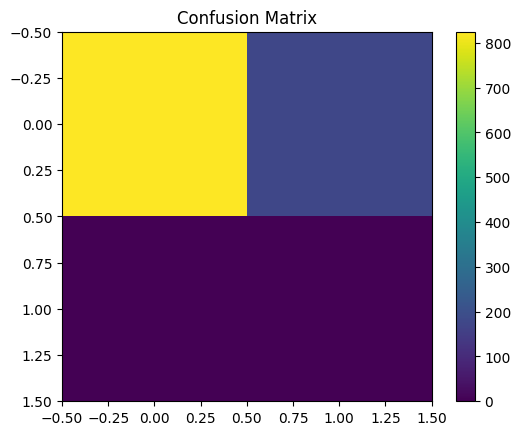

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

predictions = trainer.predict(tokenized_datasets["test"].select(range(1000)))
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

Fine-tuning improves performance because:

Pretrained model already learned language patterns.

Fine-tuning adapts weights specifically for sentiment classification.

Domain-specific patterns are learned.

Metrics improve compared to pipeline model.